In [1]:
import zipfile
import xarray as xr
import io
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
# from join_data_ import concat_all_zips
import os

In [35]:
file = "./data_output/mean_surface_direct_short_wave_radiation_flux_2006_A/data.grib"
dado = xr.open_dataset(file, engine="cfgrib", decode_times=True, decode_timedelta=True)
# criar valid_time como coordenada
# 1. Criar valid_time como DataArray (broadcast sobre step)
valid_time = dado["time"] + dado["step"]
dado = dado.assign_coords(valid_time=(("time", "step"), valid_time.data))

dado_step_mean = dado.mean(dim="step")
dado_diario = dado_step_mean.resample(time="1D").mean()
# dado = dado.resample(time="1D").mean()

surface_downwelling_shortwave = dado_diario.to_dataframe().reset_index()
surface_downwelling_shortwave.head()

Ignoring index file './data_output/mean_surface_direct_short_wave_radiation_flux_2006_A/data.grib.5b7b6.idx' older than GRIB file


,time,latitude,longitude,avg_sdirswrf,number,surface
0,2005-12-31,5.0,-50.0,0.000000,0,0.0
1,2006-01-01,5.0,-50.0,103.280067,0,0.0
2,2006-01-02,5.0,-50.0,93.541611,0,0.0
3,2006-01-03,5.0,-50.0,77.556503,0,0.0
4,2006-01-04,5.0,-50.0,95.211830,0,0.0


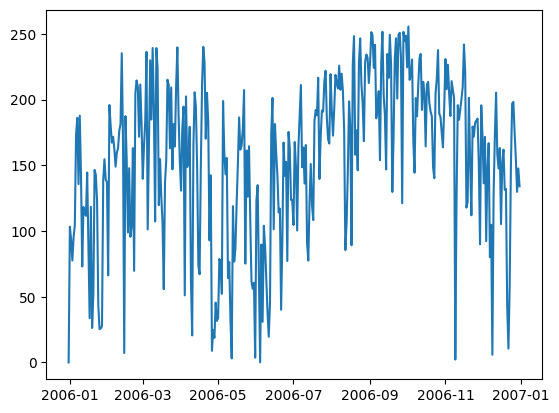

In [37]:
plt.plot(surface_downwelling_shortwave['time'],surface_downwelling_shortwave['avg_sdirswrf'])

In [36]:
print(dado_diario)

<xarray.Dataset> Size: 4kB
Dimensions:       (time: 366, latitude: 1, longitude: 1)
Coordinates:
    number        int64 8B 0
    surface       float64 8B 0.0
  * latitude      (latitude) float64 8B 5.0
  * longitude     (longitude) float64 8B -50.0
  * time          (time) datetime64[ns] 3kB 2005-12-31 2006-01-01 ... 2006-12-31
Data variables:
    avg_sdirswrf  (time, latitude, longitude) float32 1kB 0.0 103.3 ... 134.1


In [21]:
np.unique(surface_downwelling_shortwave['longitude'])

array([-50.])

In [26]:
surface_downwelling_shortwave.head(15)

,time,step,latitude,longitude,avg_sdirswrf,number,surface
0,2005-12-31,0 days 01:00:00,5.0,-50.0,NaN,0,0.0
1,2005-12-31,0 days 02:00:00,5.0,-50.0,NaN,0,0.0
2,2005-12-31,0 days 03:00:00,5.0,-50.0,NaN,0,0.0
3,2005-12-31,0 days 04:00:00,5.0,-50.0,NaN,0,0.0
4,2005-12-31,0 days 05:00:00,5.0,-50.0,NaN,0,0.0
5,2005-12-31,0 days 06:00:00,5.0,-50.0,0.000000,0,0.0
6,2005-12-31,0 days 07:00:00,5.0,-50.0,0.000000,0,0.0
7,2005-12-31,0 days 08:00:00,5.0,-50.0,0.000000,0,0.0
8,2005-12-31,0 days 09:00:00,5.0,-50.0,0.000000,0,0.0
9,2005-12-31,0 days 10:00:00,5.0,-50.0,0.000000,0,0.0


In [24]:
surface_downwelling_shortwave.describe()

,time,step,latitude,longitude,number,surface,valid_time,avg_sdirswrf
count,8772,8772,8772.0,8772.0,8772.0,8772.0,8772,8760.000000
mean,2006-07-02 05:59:59.999999872,0 days 06:30:00,5.0,-50.0,0.0,0.0,2006-07-02 12:30:00.000000128,154.961899
min,2005-12-31 18:00:00,0 days 01:00:00,5.0,-50.0,0.0,0.0,2005-12-31 19:00:00,0.000000
25%,2006-04-01 18:00:00,0 days 03:45:00,5.0,-50.0,0.0,0.0,2006-04-02 03:45:00,0.000000
50%,2006-07-02 06:00:00,0 days 06:30:00,5.0,-50.0,0.0,0.0,2006-07-02 12:30:00,1.843782
75%,2006-10-01 18:00:00,0 days 09:15:00,5.0,-50.0,0.0,0.0,2006-10-01 21:15:00,279.616760
max,2006-12-31 18:00:00,0 days 12:00:00,5.0,-50.0,0.0,0.0,2007-01-01 06:00:00,933.062988
std,NaN,0 days 03:27:08.097522406,0.0,0.0,0.0,0.0,NaN,229.611145


In [14]:
file = "./data_output/surface_downwelling_shortwave_2006_2020.nc"
dado = xr.open_dataset(file, engine="h5netcdf")
surface_downwelling_shortwave = dado.to_dataframe().reset_index()
surface_downwelling_shortwave.head()

,lat,nb2,lon,time,lat_bnds,lon_bnds,record_status,time_bnds,SIS,SISCLS,SIS_dms,SIS_nobs,SISCLS_dms,SIS_stdv
0,-7.875,0,-56.375,2006-01-01,-8.0,-56.5,0,2006-01-01,210.651672,325.110168,31.0,3059.0,31.0,60.861355
1,-7.875,0,-56.375,2006-02-01,-8.0,-56.5,0,2006-02-01,177.381744,324.785492,28.0,2660.0,28.0,74.727600
2,-7.875,0,-56.375,2006-03-01,-8.0,-56.5,0,2006-03-01,209.452957,315.999939,31.0,2884.0,31.0,54.535168
3,-7.875,0,-56.375,2006-04-01,-8.0,-56.5,0,2006-04-01,192.822037,290.420349,30.0,2693.0,30.0,60.276154
4,-7.875,0,-56.375,2006-05-01,-8.0,-56.5,0,2006-05-01,187.008408,259.305969,31.0,2702.0,31.0,40.792301


SIS → radiação solar “bruta” na superfície.

SISCLS → radiação solar estimada sem nuvens (clear-sky).

_dms → média diária mensal.

_nobs → quantas observações entraram na média.

_stdv → variabilidade da radiação no período ou área.

In [16]:
# colunas de tempo
surface_downwelling_shortwave["year"] = surface_downwelling_shortwave["time"].dt.year
surface_downwelling_shortwave["month"] = surface_downwelling_shortwave["time"].dt.month
surface_downwelling_shortwave["day"] = surface_downwelling_shortwave["time"].dt.day
surface_downwelling_shortwave["quarter"] = surface_downwelling_shortwave["time"].dt.quarter


In [17]:
def season_hs(month):
    if month in [12, 1, 2]:
        return "summer"
    elif month in [3, 4, 5]:
        return "autumn"
    elif month in [6, 7, 8]:
        return "winter"
    else:
        return "spring"

surface_downwelling_shortwave["season"] = surface_downwelling_shortwave["month"].apply(season_hs)

In [18]:
len(surface_downwelling_shortwave.index)

2747520

In [21]:
surface_downwelling_shortwave.head()

,lat,nb2,lon,time,lat_bnds,lon_bnds,record_status,time_bnds,SIS,SISCLS,SIS_dms,SIS_nobs,SISCLS_dms,SIS_stdv,year,month,day,quarter,season
0,-7.875,0,-56.375,2006-01-01,-8.0,-56.5,0,2006-01-01,210.651672,325.110168,31.0,3059.0,31.0,60.861355,2006,1,1,1,summer
1,-7.875,0,-56.375,2006-02-01,-8.0,-56.5,0,2006-02-01,177.381744,324.785492,28.0,2660.0,28.0,74.727600,2006,2,1,1,summer
2,-7.875,0,-56.375,2006-03-01,-8.0,-56.5,0,2006-03-01,209.452957,315.999939,31.0,2884.0,31.0,54.535168,2006,3,1,1,autumn
3,-7.875,0,-56.375,2006-04-01,-8.0,-56.5,0,2006-04-01,192.822037,290.420349,30.0,2693.0,30.0,60.276154,2006,4,1,2,autumn
4,-7.875,0,-56.375,2006-05-01,-8.0,-56.5,0,2006-05-01,187.008408,259.305969,31.0,2702.0,31.0,40.792301,2006,5,1,2,autumn


In [22]:
surface_downwelling_shortwave.tail()

,lat,nb2,lon,time,lat_bnds,lon_bnds,record_status,time_bnds,SIS,SISCLS,SIS_dms,SIS_nobs,SISCLS_dms,SIS_stdv,year,month,day,quarter,season
2747515,9.875,1,-30.125,2020-08-01,10.0,-30.0,0,2020-09-01,210.354370,298.407318,31.0,4812.0,31.0,80.699959,2020,8,1,3,winter
2747516,9.875,1,-30.125,2020-09-01,10.0,-30.0,0,2020-10-01,211.232071,294.487793,30.0,4497.0,30.0,87.892998,2020,9,1,3,spring
2747517,9.875,1,-30.125,2020-10-01,10.0,-30.0,0,2020-11-01,246.690109,285.035461,31.0,4531.0,31.0,51.195045,2020,10,1,4,spring
2747518,9.875,1,-30.125,2020-11-01,10.0,-30.0,0,2020-12-01,205.539581,256.952332,30.0,4159.0,30.0,65.633652,2020,11,1,4,spring
2747519,9.875,1,-30.125,2020-12-01,10.0,-30.0,0,2021-01-01,153.551849,227.441879,31.0,4357.0,31.0,57.462051,2020,12,1,4,summer


In [24]:
indices = surface_downwelling_shortwave.index[surface_downwelling_shortwave["time"] == "2006-01-01"].tolist()
len(indices)

15264

In [ ]:
from scipy.interpolate import griddata
import numpy as np
df_day = surface_downwelling_shortwave.loc[indices, ["lat", "lon", "SIS"]]
# dados originais
x = df_day["lon"].values
y = df_day["lat"].values
v = df_day["SIS"].values

# grade 2D alvo
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
XI, YI = np.meshgrid(xi, yi)

# interpolação
Z = griddata((x, y), v, (XI, YI), method='linear')  # method='nearest' ou 'cubic'


In [42]:
Z.max()


np.float64(307.2225341796875)

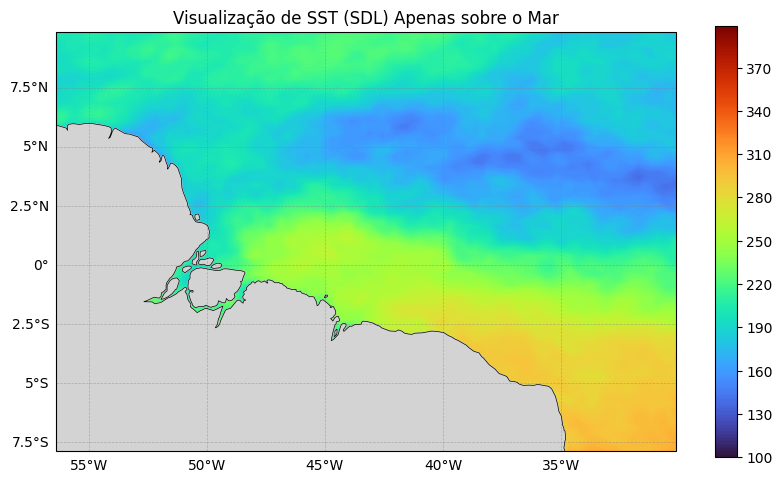

In [43]:
data_crs = ccrs.PlateCarree()
plot_crs = ccrs.PlateCarree() 

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=plot_crs)

extent = [
    float(XI.min()),
    float(XI.max()),
    float(YI.min()),
    float(YI.max())
]
ax.set_extent(extent, crs=data_crs)

min_val = 100
max_val = 400
n = 1

plot = ax.contourf(
    XI, 
    YI, 
    Z, 
    levels=np.arange(min_val, max_val, n),
    cmap="turbo",
    transform=data_crs
)

land_50m = cfeature.NaturalEarthFeature(
    'physical',
    'land',
    '50m',
    edgecolor='face',
    facecolor='lightgray' 
)

ax.add_feature(land_50m, zorder=2)
ax.coastlines(resolution='50m', color='black', linewidth=0.5, zorder=3)

plt.colorbar(plot, ax=ax, orientation='vertical', shrink=0.7)
ax.set_title(f'Visualização de SST (SDL) Apenas sobre o Mar')

gl = ax.gridlines(crs=data_crs, draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.show()